# Team
- Stefanos Panteli UC1065916<br>
spante01@ucy.ac.cy

- Evangelia Krigkou UC1067400<br>
ekrigk01@ucy.ac.cy

- Rafael Chrysanthou UC1064747<br>
rchrys03@ucy.ac.cy

- Kyprianos Erakleous UC1058854<br>
kerakl02@ucy.ac.cy


GitHub: [https://github.com/stefanosPanteli/EPL445](https://github.com/stefanosPanteli/EPL445)

# Imports

In [1]:
import os
if not os.path.exists('cat-21'):
    os.mkdir('cat-21')

if not os.path.exists('cat-21/training'):
    os.mkdir('cat-21/training')
if not os.path.exists('cat-21/validation'):
    os.mkdir('cat-21/validation')

if not os.path.exists('best_models'):
    os.mkdir('best_models')

dirs = ['temporal']
for d in dirs:
    if not os.path.exists(f'best_models/{d}/'): os.mkdir(f'best_models/{d}/')
    if not os.path.exists(f'best_models/{d}/balanced/'): os.mkdir(f'best_models/{d}/balanced/')

In [2]:
from sklearn.metrics import (
    accuracy_score, precision_score,recall_score, f1_score, roc_auc_score,
    confusion_matrix as sk_confusion_matrix, ConfusionMatrixDisplay
)

from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
import torch

from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

import cv2

import pandas as pd
import numpy as np

from typing import Callable, Any, List, Dict, Tuple, Optional, Literal
from collections import Counter
from pathlib import Path
import random

# Contants & Globals

In [3]:
KEEP_NOT_INIT = not True

UNDERLINE = '\033[4m'
BOLD = '\033[1m'
CYAN = '\033[36m'
WHITE = '\033[37m'
RESET = '\033[0m'
def nicely_print(title: str, content: str= '') -> None:
    '''
    `nicely_print` prints a title and content in a nice format.

    `Args:`
        title (str): The title of the section. Will be Underlined, Bold, Cyan.
        content (str): The content of the section. Will be Bold, White.
    '''
    print(f'{UNDERLINE}{BOLD}{CYAN}{title}{RESET}', end=' ')
    print(f'{BOLD}{WHITE}{content}{RESET}\n')

label_to_int = {}
if KEEP_NOT_INIT:
    label_to_int['not_initialized'] = 11
label_to_int.update({
    'incision': 0,
    'viscoelasticum': 1,
    'rhexis': 2,
    'hydrodissektion': 3,
    'phako': 4,
    'irrigation-aspiration': 5,
    'kapselpolishing': 6,
    'linsenimplantation': 7,
    'visco-absaugung': 8,
    'tonisieren': 9,
    'antibiotikum': 10
})
int_to_label = {v: k for k, v in label_to_int.items()}

phase_order = [label.lower() for label in label_to_int.keys()]

phase_to_color = {
    label: plt.get_cmap("tab20")(i % plt.get_cmap("tab20").N)
    for i, label in enumerate((['not_initialized'] + phase_order if not KEEP_NOT_INIT else phase_order))
}

device = 'cuda' if torch.cuda.is_available() else 'cpu'
num_classes = len(label_to_int.keys())

## Init Data

In [4]:
def load_case_annotations(csv_path: Path) -> Dict[int, int | str]:
    '''
    `load_case_annotations` loads the annotations for a single case.
        Reads the CSV file and returns a dictionary {frame_number: label}.

    `Args:`
        csv_path (Path): The path to the CSV file.

    `Returns:`
        Dict[int, int | str]: A dictionary of annotations.
    '''
    df = pd.read_csv(csv_path, names= ['frame_no', 'label'])
    if not KEEP_NOT_INIT:
        df = df[ df['label'] != 'not_initialized' ]
    return {
        int(frame): label
        for frame, label in zip(df['frame_no'], df['label'])
    }


def build_cases_dict(root_dir: str) -> Dict[str, Dict[int, Dict]]:
    '''
    `build_cases_dict` builds a dictionary for every case in the dataset.

    `Args:`
        root_dir (str): The root directory of the dataset.

    `Returns:`
        Dict[str, Dict[int, Dict]]: A dictionary of cases.
        * Format: { 'train/val': { case_id: { 'video_path': str, 'annotations': Dict }
    '''
    root = Path(root_dir)

    cases = {
        'train': {},
        'val': {}
    }

    split_map = {
        'training': 'train',
        'validation': 'val'
    }

    for folder_name, split_name in split_map.items():
        split_dir = root / folder_name

        if not split_dir.exists():
            print(f'Warning: folder not found -> {split_dir}')
            continue

        for video_path in sorted(split_dir.glob('case_*.mp4')):
            case_name = video_path.stem # Removes .mp4
            csv_path = split_dir / f'{case_name}.csv'

            if not csv_path.exists():
                print(f'Warning: missing CSV for {video_path.name}')
                continue

            try:
                case_id = int(case_name.split("_")[1])
            except (IndexError, ValueError):
                print(f'Warning: could not parse case id from {video_path.name}')
                continue

            annotations = load_case_annotations(csv_path)

            cases[split_name][case_id] = {
                'video_path': str(video_path),
                'annotations': annotations
            }

    return cases

nicely_print('Fetching', 'Video Paths & Annotations')
cases = build_cases_dict('cat-21')
annotations_only = {
    case_id: case_info['annotations']
    for case_id, case_info in cases['train'].items()
}

if cases['train'] == {}:  print('No train videos provided')
if cases['val'] == {}:    print('No validation videos provided')

if cases['train'] != {} and cases['val'] != {}:
    for split, cases_dict in cases.items():
        print(f'Split: {split}')
        for case_id, case_info in cases_dict.items():
            last_label = ''
            print(
                f'  Case ID: {case_id}' \
                f'  - Video Path: {case_info["video_path"]}' \
                f'  - Annotations:'
            )
            for frame, label in case_info['annotations'].items():
                if label == last_label: continue
                print(f'      {frame:>5} - {label}')
                last_label = label
            print()
        print()

Fetching Video Paths & Annotations

Split: train
  Case ID: 1  - Video Path: cat-21/training/case_01.mp4  - Annotations:
         68 - Incision
       1043 - Viscoelasticum
       1228 - Rhexis
       2118 - Hydrodissektion
       3478 - Phako
       6864 - Irrigation-Aspiration
       7727 - Kapselpolishing
       8473 - Viscoelasticum
       8683 - Linsenimplantation
       9482 - Visco-Absaugung
      14138 - Tonisieren
      14623 - Antibiotikum

  Case ID: 2  - Video Path: cat-21/training/case_02.mp4  - Annotations:
         20 - Incision
        357 - Viscoelasticum
        572 - Rhexis
       1030 - Hydrodissektion
       1432 - Phako
       3032 - Irrigation-Aspiration
       3963 - Kapselpolishing
       4330 - Viscoelasticum
       4495 - Linsenimplantation
       4853 - Visco-Absaugung
       5867 - Tonisieren
       6167 - Antibiotikum

  Case ID: 3  - Video Path: cat-21/training/case_03.mp4  - Annotations:
        228 - Incision
        517 - Viscoelasticum
        678 - R

# Preprocessing

## Label Conversion

In [5]:
""" Label Conversion Functions """
# l2i
def convert_label2int(label: str) -> int:
    return label_to_int.get(label.lower(), -1)

# i2l
def convert_int2label(label: int) -> str:
    return int_to_label.get(label, 'unknown')

## Getting the Frames

In [6]:
""" Getting the frames """
# Sampling every X frames, and getting metadata (only, or as well as frames)
def sample_case_with_metadata(
    video_path: str,
    annotations: Dict[int, str],
    functions_to_apply: List[Callable[[cv2.Mat], cv2.Mat]]= None,
    frame_step: int= 1,
) -> Tuple[Optional[List[np.ndarray]], List[Dict[str, Any]], List[int]]:
    '''
    `sample_case_with_metadata` samples the frames of a video, and returns them with their corresponding label.
                                Each frame will be processed with all the functions in `functions_to_apply`, in the given order.
                                Metadata will be extracted from the frames with all the functions in `metadata_to_extract`, in the given order.

    `Args:`
        video_path (str): The path to the video.
        annotations (Dict[int, str]): The frame-to-label mapping.
        functions_to_apply (List[Callable[[cv2.Mat], cv2.Mat]]): A list of functions to apply to the frames.
        * Callable Format: Must accept an image, and return an image.
        frame_step (int): The step used to subsample frames.
        metadata_to_extract (List[CallableCallable[[cv2.Mat], Dict[str, Any]]]): A list of functions to extract metadata from the frames.
        * Callable Format: Must accept an image, and return a dict with string keys and whatever values.
        return_frame (bool): Whether to return the frames.

    `Returns:`
        (Tuple[List[np.ndarray], List[Dict[str, Any]], List[int]]) Three lists containing the sampled frames, metadata and their annotation.
        * Format: (
            [ frame, ... ],
            [ { 'key': value, ...}, ... ]
            [ int_label, ... ]
        )
    '''
    if functions_to_apply is None:
        functions_to_apply = []

    # Open video
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f'Could not open video at {video_path}')

    # Calculate total frames
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Read every frame and skip the unwanted
    frames = []
    metadata = []
    labels = []
    frame_idx = -1
    while True:
        frame_idx += 1 # Next frame
        # Read frame
        ret, frame = cap.read()
        if not ret: break

        # Skip not_init
        if frame_idx not in annotations: continue
        # Skip if not needed
        if frame_idx % frame_step != 0:  continue

        # Always append frame/total_frames
        extracted_metadata = {}
        extracted_metadata.update({'frame_norm': frame_idx / total_frames})

        # Sequentially apply all functions
        for func in functions_to_apply:
            frame = func(frame)

        frames.append(frame)
        metadata.append(extracted_metadata)
        labels.append(convert_label2int(annotations[frame_idx]))

    cap.release()

    return frames, metadata, labels

---

# Methods - Models

## Evaluation

In [7]:
def bar_compare(y_test: np.ndarray, y_preds: dict[str, np.ndarray]) -> None:
    '''
    `bar_compare` draws horizontal bars comparing the true labels with predicted labels.

    `Args:`
        `y_test (np.ndarray)`: The true labels.
        `y_preds (dict[str, np.ndarray])`: The predicted labels per model.
        * Format: { 'Model Name': np.ndarray, ... }
    '''
    y_test = np.asarray(y_test)
    y_preds = {name: np.asarray(pred) for name, pred in y_preds.items()}

    n = len(y_test)
    row_names = ['Real'] + list(y_preds.keys())
    row_data = [y_test] + [y_preds[name] for name in y_preds]

    for name, pred in y_preds.items():
        if len(pred) != n:
            raise ValueError(f'Length mismatch for {name}: got {len(pred)}, expected {n}')

    fig_height = max(2.5, 0.7 * len(row_names))
    fig, ax = plt.subplots(figsize=(16, fig_height))

    bar_height = 0.6

    def draw_blocks(labels: np.ndarray, y_base: float) -> None:
        start = 0
        current = labels[0]

        for i in range(1, len(labels) + 1):
            if i == len(labels) or labels[i] != current:
                phase = int_to_label[int(current)]
                color = phase_to_color[phase]
                ax.add_patch(Rectangle((start, y_base), i - start, bar_height, color=color))
                if i < len(labels):
                    start = i
                    current = labels[i]

    y_positions = list(range(len(row_data)))[::-1]

    for y_pos, labels in zip(y_positions, row_data):
        draw_blocks(labels, y_pos)

    ax.set_xlim(0, n)
    ax.set_ylim(-0.2, len(row_data) - 0.2 + bar_height)
    ax.set_yticks([y + bar_height / 2 for y in y_positions])
    ax.set_yticklabels(row_names)
    ax.set_xlabel('Sample Index')
    ax.set_title('True vs Predicted Phases')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    handles = [
        Rectangle((0, 0), 1, 1, color=color, label=phase)
        for phase, color in phase_to_color.items()
    ]
    ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

def plot_confusion_matrices(
    y_test: np.ndarray,
    y_preds: dict[str, np.ndarray],
    normalize: Optional[Literal['true', 'pred', 'all']] = None,
    ncols: int = 3
) -> None:
    '''
    `plot_confusion_matrices` draws one confusion matrix per model
    inside a single figure.

    `Args:`
        `y_test (np.ndarray)`: The true labels.
        `y_preds (dict[str, np.ndarray])`: The predicted labels per model.
        * Format: { 'Model Name': np.ndarray, ... }
        `normalize (str | None)`: Normalization mode for sklearn confusion_matrix.
        * Options: None, 'true', 'pred', 'all'
        `ncols (int)`: Number of confusion matrices per row.
    '''
    y_test = np.asarray(y_test)
    y_preds = {name: np.asarray(pred) for name, pred in y_preds.items()}

    labels = sorted(int_to_label.keys())
    display_labels = [int_to_label[i] for i in labels]

    model_names = list(y_preds.keys())
    n_models = len(model_names)

    if n_models == 0: raise ValueError('`y_preds` is empty.')
    if ncols <= 0: raise ValueError('`ncols` must be a positive integer.')

    nrows = int(np.ceil(n_models / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 5 * nrows))
    axes = np.atleast_1d(axes).flatten()
    for ax, name in zip(axes, model_names):
        pred = y_preds[name]
        if len(pred) != len(y_test):
            raise ValueError(f'Length mismatch for {name}: got {len(pred)}, expected {len(y_test)}')

        cm = sk_confusion_matrix(y_test, pred, labels=labels, normalize=normalize)

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
        disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
        ax.set_title(f'Confusion Matrix - {name}')

    # Hide unused subplots
    for ax in axes[n_models:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

def classification_results_df(
    y_true: np.ndarray,
    y_preds: dict[str, np.ndarray],
    y_probas: Optional[dict[str, np.ndarray]] = None,
    average: str = 'weighted'
) -> pd.DataFrame:
    '''
    `classification_results_df` computes a dataframe with common classification metrics.

    `Args:`
        `y_true (np.ndarray)`: The true labels.
        `y_preds (dict[str, np.ndarray])`: The predicted labels per model.
        * Format: { 'Model Name': np.ndarray, ... }
        `y_probas (dict[str, np.ndarray] | None)`: Optional predicted probabilities per model.
        * Binary format: { 'Model Name': np.ndarray of shape (n_samples,) or (n_samples, 2), ... }
        * Multiclass format: { 'Model Name': np.ndarray of shape (n_samples, n_classes), ... }
        `average (str)`: Averaging mode for multiclass metrics.
        * Common options: 'weighted', 'macro', 'micro'

    `Returns:`
        (pd.DataFrame) A dataframe with one row per model and one column per metric.
    '''
    y_true = np.asarray(y_true)
    y_preds = {name: np.asarray(pred) for name, pred in y_preds.items()}
    y_probas = {} if y_probas is None else {name: np.asarray(proba) for name, proba in y_probas.items()}

    unique_labels = np.unique(y_true)
    rows = []

    for name, y_pred in y_preds.items():
        if len(y_pred) != len(y_true):
            raise ValueError(f'Length mismatch for {name}: got {len(y_pred)}, expected {len(y_true)}')

        row = {
            'Model': name,
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, average=average, zero_division=0),
            'Recall': recall_score(y_true, y_pred, average=average, zero_division=0),
            'F1': f1_score(y_true, y_pred, average='macro', zero_division=0),
            'Weighted F1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        }

        try:
            row['ROC AUC'] = roc_auc_score(
                y_true, y_probas[name], multi_class='ovr', average=average
            )
        except Exception:
            row['ROC AUC'] = np.nan

        rows.append(row)

    df = pd.DataFrame(rows)

    metric_order = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'Weighted F1', 'ROC AUC']
    existing_cols = [col for col in metric_order if col in df.columns]
    df = df[existing_cols]

    if all(df['ROC AUC'].isna()): df = df.drop(columns=['ROC AUC'])

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].round(4)

    # print(df)
    return df

def plot_per_epoch(losses: Dict[str, List[float]], acc: Dict[str, List[float]], title: str) -> None:
    '''
    `plot_per_epoch` plots the losses and accuracies per epoch.

    `Args:`
        `losses (Dict[str, List[float]])`: The losses per epoch.
        * Format: { 'train': [float, ...], 'val': [float, ...] }
        `acc (Dict[str, List[float]])`: The accuracies per epoch.
        * Format: { 'train': [float, ...], 'val': [float, ...] }
    '''
    if 'train' not in losses or 'val' not in losses:
        raise ValueError("`losses` must contain the keys 'train' and 'val'.")

    if 'train' not in acc or 'val' not in acc:
        raise ValueError("`acc` must contain the keys 'train' and 'val'.")

    if not all(isinstance(v, list) for v in losses.values()):
        raise TypeError('All values in `losses` must be lists.')

    if not all(isinstance(v, list) for v in acc.values()):
        raise TypeError('All values in `acc` must be lists.')

    n_epochs_loss = len(losses['train'])
    n_epochs_acc = len(acc['train'])

    if len(losses['val']) != n_epochs_loss:
        raise ValueError("`losses['train']` and `losses['val']` must have the same length.")

    if len(acc['val']) != n_epochs_acc:
        raise ValueError("`acc['train']` and `acc['val']` must have the same length.")

    epochs_loss = list(range(1, n_epochs_loss + 1))
    epochs_acc = list(range(1, n_epochs_acc + 1))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_loss, losses['train'], label='Train Loss')
    plt.plot(epochs_loss, losses['val'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_acc, acc['train'], label='Train Accuracy')
    plt.plot(epochs_acc, acc['val'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def majority_sliding_window(y_pred: np.ndarray, window_size: int) -> np.ndarray:
    if window_size % 2 == 0 or window_size < 1:
        raise ValueError('window_size must be a positive odd integer')

    y_pred = np.asarray(y_pred)
    smoothed = np.empty_like(y_pred)

    half = window_size // 2

    for i in range(len(y_pred)):
        start = max(0, i - half)
        end = min(len(y_pred), i + half + 1)

        window = y_pred[start:end]
        counts = Counter(window)

        # Majority vote
        max_count = max(counts.values())
        candidates = [label for label, count in counts.items() if count == max_count]

        # Tie-break: keep original label if it is among the tied labels
        if y_pred[i] in candidates:
            smoothed[i] = y_pred[i]
        else:
            smoothed[i] = candidates[0]

    return smoothed

def evaluate_results(predictions, model_prefix, together= False):
    all_y_true = []
    all_y_pred_raw = [] # Store raw predictions for global evaluation
    all_y_pred_win3 = []
    all_y_pred_win5 = []
    all_y_pred_win7 = []
    all_y_pred_win15 = []
    all_y_pred_win15_15 = []
    all_y_pred_win31 = []

    for cid, result in predictions.items():
        print(f'Case {cid}: {len(result["y_true"])} frames')

        y_true = np.asarray(result['y_true'])
        y_pred = np.asarray(result['y_pred'])

        # Bar compare is always per-case
        pred_for_bar_compare = {
            f'{model_prefix}': y_pred,
            f'{model_prefix}_win3': majority_sliding_window(y_pred, 3),
            f'{model_prefix}_win5': majority_sliding_window(y_pred, 5),
            f'{model_prefix}_win7': majority_sliding_window(y_pred, 7),
            f'{model_prefix}_win15': majority_sliding_window(y_pred, 15),
            f'{model_prefix}_win15_15': majority_sliding_window(majority_sliding_window(y_pred, 15), 15),
            f'{model_prefix}_win31': majority_sliding_window(y_pred, 31)
        }
        bar_compare(y_true, {f'Case {cid}: ' + k: v for k, v in pred_for_bar_compare.items()})
        print()

        # If together is False, display CM and metrics per case
        if not together:
            plot_confusion_matrices(y_true, {f'Case {cid}: ' + k: v for k, v in pred_for_bar_compare.items()})
            print()
            display(classification_results_df(y_true, {f'Case {cid}: ' + k: v for k, v in pred_for_bar_compare.items()}))
            print()
        else:
            # Accumulate predictions for global evaluation
            all_y_true.extend(y_true)
            all_y_pred_raw.extend(pred_for_bar_compare[f'{model_prefix}'])
            all_y_pred_win3.extend(pred_for_bar_compare[f'{model_prefix}_win3'])
            all_y_pred_win5.extend(pred_for_bar_compare[f'{model_prefix}_win5'])
            all_y_pred_win7.extend(pred_for_bar_compare[f'{model_prefix}_win7'])
            all_y_pred_win15.extend(pred_for_bar_compare[f'{model_prefix}_win15'])
            all_y_pred_win15_15.extend(pred_for_bar_compare[f'{model_prefix}_win15_15'])
            all_y_pred_win31.extend(pred_for_bar_compare[f'{model_prefix}_win31'])

    # After iterating through all cases, if together is True, display global metrics
    if together:
        print(f'\n--- Overall Results for all cases ({len(all_y_true)} frames) ---')
        all_y_true_np = np.asarray(all_y_true)

        pred_all_global = {
            f'{model_prefix}': np.asarray(all_y_pred_raw),
            f'{model_prefix}_win3': np.asarray(all_y_pred_win3),
            f'{model_prefix}_win5': np.asarray(all_y_pred_win5),
            f'{model_prefix}_win7': np.asarray(all_y_pred_win7),
            f'{model_prefix}_win15': np.asarray(all_y_pred_win15),
            f'{model_prefix}_win15_15': np.asarray(all_y_pred_win15_15),
            f'{model_prefix}_win31': np.asarray(all_y_pred_win31)
        }
        plot_confusion_matrices(all_y_true_np, pred_all_global)
        print()
        display(classification_results_df(all_y_true_np, pred_all_global))
        print()

## Dataset Balancing

In [8]:
class BalancedDataset:
    def _apply_rotate(self, frames):
        angle = random.uniform(-5.0, 5.0)
        out = []
        for frame in frames:
            h, w = frame.shape[:2]
            M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
            aug = cv2.warpAffine(frame, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
            out.append(aug)
        return out

    def _apply_brightness(self, frames):
        delta = random.uniform(-10, 10)
        out = []
        for frame in frames:
            aug = np.clip(frame.astype(np.float32) + delta, 0, 255).astype(np.uint8)
            out.append(aug)
        return out

    def _apply_contrast(self, frames):
        alpha = random.uniform(0.95, 1.05)
        out = []
        for frame in frames:
            aug = np.clip(frame.astype(np.float32) * alpha, 0, 255).astype(np.uint8)
            out.append(aug)
        return out

    def _apply_noise(self, frames):
        sigma = random.uniform(3, 7)
        out = []
        for frame in frames:
            noise = np.random.normal(0, sigma, frame.shape)
            aug = np.clip(frame.astype(np.float32) + noise, 0, 255).astype(np.uint8)
            out.append(aug)
        return out

    def apply_clip_augmentation(self, frames):
        aug_type = random.choice(['rotate', 'brightness', 'contrast', 'noise'])
        return getattr(self, f'_apply_{aug_type}')(frames)

def print_dataset_frame_balance(dataset, label_to_int):
    '''
    Prints the frame-label balance induced by the dataset itself.

    Compatible with:
    - dict samples:
        { 'case_id': ..., 'frames': ..., 'labels': ..., 'frame_norms': ..., 'augment': ... }

    - frame-level tuple samples:
        (frame, label)
        (frame, label, frame_norm, case_id)
        (frame, label, frame_norm, case_id, augment)

    - clip-level tuple samples:
        (case_id, clip_frames, clip_labels, clip_frame_norms)

    - temporal-window tuple samples:
        (window_frames, window_norms, label, case_id)
        (window_frames, window_norms, label, case_id, augment)
    '''
    int_to_label = {v: k for k, v in label_to_int.items()}
    valid_class_ids = set(label_to_int.values())

    counter = Counter()
    total_frames = 0

    for sample in dataset.samples:
        if isinstance(sample, dict):
            labels = sample['labels']
            counter.update(labels)
            total_frames += len(labels)

        elif isinstance(sample, tuple):
            # 1. Clip-level tuples
            # (case_id, clip_frames, clip_labels, clip_frame_norms)
            if (
                len(sample) == 4 and
                isinstance(sample[0], (str, int)) and
                isinstance(sample[2], (list, tuple, np.ndarray))
            ):
                clip_labels = sample[2]
                counter.update(clip_labels)
                total_frames += len(clip_labels)

            # 2. Temporal-window tuples
            # (window_frames, window_norms, label, case_id)
            # (window_frames, window_norms, label, case_id, augment)
            elif (
                len(sample) in (4, 5) and
                isinstance(sample[0], (list, tuple)) and
                isinstance(sample[1], (list, tuple, np.ndarray)) and
                np.isscalar(sample[2]) and
                int(sample[2]) in valid_class_ids
            ):
                label = int(sample[2])
                counter.update([label])
                total_frames += 1

            # 3. Frame-level tuples
            # (frame, label)
            # (frame, label, frame_norm, case_id)
            # (frame, label, frame_norm, case_id, augment)
            elif (
                len(sample) >= 2 and
                np.isscalar(sample[1]) and
                int(sample[1]) in valid_class_ids
            ):
                label = int(sample[1])
                counter.update([label])
                total_frames += 1

            else:
                raise ValueError(f'Unsupported tuple sample format: {sample}')

        else:
            raise ValueError(f'Unsupported sample type: {type(sample)}')

    rows = []
    for cls in sorted(label_to_int.values()):
        count = counter.get(cls, 0)
        pct = 100.0 * count / total_frames if total_frames > 0 else 0.0

        rows.append({
            'Class Id': cls,
            'Label': int_to_label[cls],
            'Dataset Frames': count,
            'Percent': round(pct, 2)
        })

    df = pd.DataFrame(rows)
    print(df.sort_values('Dataset Frames', ascending=False).to_string(index=False))
    return df

## Dataset Version

As of now we have the following data already calculated:
1. cases
    ```python
    {
        'train': {
            case_id: {
                'video_path': str,
                'annotations': {
                    frame_number: str_label,
                    ...
                }
            } ,
            ... # Total of 17 cases
        },
        'val': {
            case_id: {
                'video_path': str,
                'annotations': {
                    frame_number: str_label,
                    ...
                }  
            },
            ... # Total of 4 cases
        }
    }
    ```
2. label_to_int
    ```python
    {
        'not_initialized': 11, # Optional if KEEP_NOT_INIT
        'incision': 0,
        'viscoelasticum': 1,
        'rhexis': 2,
        'hydrodissektion': 3,
        'phako': 4,
        'irrigation-aspiration': 5,
        'kapselpolishing': 6,
        'linsenimplantation': 7,
        'visco-absaugung': 8,
        'tonisieren': 9,
        'antibiotikum': 10
    }
    ```

## Getting Train & Test Sets

In [9]:
# Functions to use to pre process the frames
processing_functions = [
    lambda frame: cv2.resize(frame, (224, 224)),
    lambda frame: cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
]

# Frame step to sample every X frames
frame_step = 5

In [10]:
parsed_cases_train = {}
print('Training Cases:')
for case_id, train_case in cases['train'].items():
    print(f'- Processing case {case_id}')
    video_path = train_case['video_path']
    annotations = train_case['annotations']
    frames, metadata, labels = sample_case_with_metadata(
        video_path,
        annotations,
        processing_functions,
        frame_step
    )
    parsed_cases_train[case_id] = {
        'frames': frames,
        'metadata': metadata,
        'labels': labels
    }

nicely_print('Cases of the Pipeline', 'Training & Evaluation')
print('Validation Cases:')
parsed_cases_val = {}
for case_id, val_case in cases['val'].items():
    print(f'- Processing case {case_id}')
    video_path = val_case['video_path']
    annotations = val_case['annotations']
    frames, metadata, labels = sample_case_with_metadata(
        video_path,
        annotations,
        processing_functions,
        frame_step
    )
    parsed_cases_val[case_id] = {
        'frames': frames,
        'metadata': metadata,
        'labels': labels
    }

Training Cases:
- Processing case 1
- Processing case 2
- Processing case 3
- Processing case 4
- Processing case 5
- Processing case 6
- Processing case 7
- Processing case 8
- Processing case 9
- Processing case 10
- Processing case 11
- Processing case 12
- Processing case 13
- Processing case 14
- Processing case 15
- Processing case 16
- Processing case 17
Cases of the Pipeline Training & Evaluation

Validation Cases:
- Processing case 18
- Processing case 19
- Processing case 20
- Processing case 21


In [11]:
# Compute class_weights
all_train_labels = []
for case_id, info in parsed_cases_train.items():
    all_train_labels.extend(info['labels'])

label_counts = Counter(all_train_labels)
total = sum(label_counts.values())

class_weights = []
for c in range(num_classes):
    count = label_counts.get(c, 1)
    class_weights.append(total / (num_classes * count))

class_weights = torch.tensor(class_weights, dtype=torch.float32)

## CNN with Temporal Pooling

### Dataset

In [33]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class BalancedTemporalDataset(Dataset, BalancedDataset):
    '''
    Balanced dataset for CNN + Temporal Pooling.
    Uses edge padding so that all frames can be used as center frames.
    Missing frames are replaced by copies of the first/last frame.
    '''

    def __init__(
        self,
        parsed_cases,
        window_size=3,
        transform=None,
        min_keep_prob=0.20,
        max_aug_copies=3,
        seed=42
    ):
        if window_size % 2 == 0:
            raise ValueError('`window_size` must be odd so there is a true center frame.')

        self.samples = []
        self.window_size = window_size
        self.transform = transform
        self.min_keep_prob = min_keep_prob
        self.max_aug_copies = max_aug_copies
        self.half_window = window_size // 2

        random.seed(seed)
        np.random.seed(seed)

        label_counter = Counter()
        temp_windows = []

        for case_id, info in parsed_cases.items():
            frames = info['frames']
            labels = info['labels']
            metadata = info['metadata']

            n = len(frames)
            if n == 0:
                continue

            for center_idx in range(n):
                window_frames = []
                window_norms = []

                for offset in range(-self.half_window, self.half_window + 1):
                    idx = center_idx + offset

                    if idx < 0:
                        idx = 0
                    elif idx >= n:
                        idx = n - 1

                    window_frames.append(frames[idx])
                    window_norms.append(metadata[idx]['frame_norm'])

                label = labels[center_idx]

                temp_windows.append((window_frames, window_norms, label, case_id))
                label_counter[label] += 1

        total = sum(label_counter.values())
        num_classes = len(label_counter)

        percentages = {
            cls: count / total
            for cls, count in label_counter.items()
        }
        mean_pct = 1.0 / num_classes

        drop_prob = {}
        aug_need = {}

        for cls, pct in percentages.items():
            if pct > mean_pct:
                drop_prob[cls] = 1.0 - (mean_pct / pct)
                aug_need[cls] = 0.0
            else:
                drop_prob[cls] = 0.0
                aug_need[cls] = (mean_pct / pct) - 1.0

        for frames, norms, label, case_id in temp_windows:
            if drop_prob[label] > 0:
                keep_prob = max(self.min_keep_prob, 1.0 - drop_prob[label])
                if random.random() > keep_prob:
                    continue

            self.samples.append((frames, norms, label, case_id, False))

            copies = int(np.floor(aug_need[label]))
            copies = min(copies, self.max_aug_copies)

            fractional = aug_need[label] - np.floor(aug_need[label])
            if copies < self.max_aug_copies and random.random() < fractional:
                copies += 1

            for _ in range(copies):
                self.samples.append((frames, norms, label, case_id, True))

    def __getitem__(self, idx):
        frames, norms, label, case_id, augment = self.samples[idx]

        if augment:
            frames = self.apply_clip_augmentation(frames)

        processed = []
        for frame in frames:
            if self.transform:
                frame = self.transform(frame)
            processed.append(frame)

        x = torch.stack(processed)                 # (T, C, H, W)
        frame_norms = torch.tensor(norms).float()  # (T,)
        label = torch.tensor(label).long()

        return x, frame_norms, label, case_id

    def __len__(self):
        return len(self.samples)

class TemporalFrameDataset(Dataset):
    '''
    Dataset for CNN + Temporal Pooling.
    Uses edge padding so that all frames can be used as center frames.

    Returns:
        - x: (T, C, H, W)
        - frame_norms: (T,)
        - y: label of the center frame
        - case_id
    '''

    def __init__(self, parsed_cases, window_size=3, transform=None):
        if window_size % 2 == 0:
            raise ValueError('`window_size` must be odd so there is a true center frame.')

        self.samples = []
        self.window_size = window_size
        self.transform = transform
        self.half_window = window_size // 2

        for case_id, info in parsed_cases.items():
            frames = info['frames']
            labels = info['labels']
            metadata = info['metadata']

            n = len(frames)
            if n == 0:
                continue

            for center_idx in range(n):
                window_frames = []
                window_norms = []

                for offset in range(-self.half_window, self.half_window + 1):
                    idx = center_idx + offset

                    if idx < 0:
                        idx = 0
                    elif idx >= n:
                        idx = n - 1

                    window_frames.append(frames[idx])
                    window_norms.append(metadata[idx]['frame_norm'])

                label = labels[center_idx]

                self.samples.append((window_frames, window_norms, label, case_id))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frames, norms, label, case_id = self.samples[idx]

        processed = []
        for frame in frames:
            if self.transform:
                frame = self.transform(frame)
            processed.append(frame)

        x = torch.stack(processed)                 # (T, C, H, W)
        frame_norms = torch.tensor(norms).float()  # (T,)
        label = torch.tensor(label).long()

        return x, frame_norms, label, case_id

nicely_print('Temporal CNN', 'Dataset')

# Get number of CPU cores for DataLoader
num_cpus = os.cpu_count()

# Unbalanced Dataset
train_dataset_temporal_unbalanced = TemporalFrameDataset(
    parsed_cases_train,
    window_size=3,
    transform=transform
)

# Balanced Dataset
train_dataset_temporal_balanced = BalancedTemporalDataset(
    parsed_cases_train,
    window_size=3,
    transform=transform,
    min_keep_prob=0.20,
    max_aug_copies=10
)
train_loader_temporal_balanced = DataLoader(train_dataset_temporal_balanced, batch_size=300, shuffle=True, num_workers=num_cpus)

# Validation Dataset
val_dataset_temporal = TemporalFrameDataset(
    parsed_cases_val,
    window_size=3,
    transform=transform
)
val_loader_temporal = DataLoader(val_dataset_temporal, batch_size=300, shuffle=False, num_workers=num_cpus)

# TODO:
# 1. window_size = 3 / 5
# 2. min_keep_prob = 0.5 / 0.4 / .. / 0.1
#   Check if majority classes are truncated too much, then raise the value
# 3. max_aug_copies = 2 / 4 / .. / 10
# 4. batch_size = 32 or more
#   Try to max out GPU RAM capacity
#
# ALL and ANY changes MUST be done to all 3 datasets.
# You may add variables for ease of use.


Temporal CNN Dataset



In [22]:
nicely_print('Temporal CNN', 'Dataset Balancing')
print('Unbalanced - Original')
print_dataset_frame_balance(train_dataset_temporal_unbalanced, label_to_int)
print('\nBalanced - Augmented')
print_dataset_frame_balance(train_dataset_temporal_balanced, label_to_int);

Temporal CNN Dataset Balancing

Unbalanced - Original
 Class Id                 Label  Dataset Frames  Percent
        4                 phako           10936    31.16
        8       visco-absaugung            5498    15.67
        5 irrigation-aspiration            5202    14.82
        2                rhexis            2720     7.75
        7    linsenimplantation            2359     6.72
        3       hydrodissektion            1914     5.45
        1        viscoelasticum            1703     4.85
        6       kapselpolishing            1642     4.68
        9            tonisieren            1489     4.24
        0              incision            1328     3.78
       10          antibiotikum             306     0.87

Balanced - Augmented
 Class Id                 Label  Dataset Frames  Percent
        5 irrigation-aspiration            3227     9.22
        6       kapselpolishing            3201     9.15
        2                rhexis            3192     9.12
        1   

### Model

In [14]:
class CNNTemporalPool(nn.Module):
    """
    CNN + Temporal Pooling model.
    - Pername kathe frame apo ResNet18
    - Pairnoume feature vector 512-dim
    - Kanoume temporal pooling (mean i max)
    - Pairnoume metadata apo frame_norm kai ta pername apo mini-MLP
    - Kanoume concat CNN + metadata kai pername sto classifier
    """

    def __init__(self, num_classes, pool_type='mean', meta_hidden=16):
        super().__init__()

        # CNN backbone
        backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        self.feature_dim = 512

        # Pooling type
        self.pool_type = pool_type

        # Mini-MLP gia metadata
        self.meta_branch = nn.Sequential(
            nn.Linear(4, meta_hidden),
            nn.ReLU(),
            nn.Linear(meta_hidden, meta_hidden)
        )

        # Teliko classifier
        self.classifier = nn.Sequential(
            nn.Linear(self.feature_dim + meta_hidden, 256),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(256, num_classes * 4),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(num_classes * 4, num_classes)
        )

    def forward(self, x, frame_norms):
        """
        x: (B, T, C, H, W)
        frame_norms: (B, T)
        """

        B, T, C, H, W = x.shape

        # CNN feature extraction
        x = x.reshape(B*T, C, H, W)
        feats = self.feature_extractor(x)      # (B*T, 512, 1, 1)
        feats = feats.flatten(1)               # (B*T, 512)
        feats = feats.reshape(B, T, self.feature_dim)

        # Temporal pooling
        if self.pool_type == 'mean':
            pooled = feats.mean(dim=1)         # (B, 512)
        else:
            pooled, _ = feats.max(dim=1)       # (B, 512)

        # Metadata features
        fn = frame_norms.unsqueeze(-1)         # (B, T, 1)
        fn_sq = fn**2
        fn_inv = 1 - fn
        fn_inv_sq = fn_inv**2

        meta_vec = torch.cat([
            fn.mean(dim=1),
            fn_sq.mean(dim=1),
            fn_inv.mean(dim=1),
            fn_inv_sq.mean(dim=1)
        ], dim=1)                              # (B, 4)

        meta_out = self.meta_branch(meta_vec)  # (B, meta_hidden)

        # Fusion
        fused = torch.cat([pooled, meta_out], dim=1)  # (B, 512+meta_hidden)

        out = self.classifier(fused)
        return out

    def freeze_weights(self, backbone_only=True, freeze_bn_running_stats=True):
        """
        Freeze model parameters.
        - backbone_only=True: freeze only `self.feature_extractor`.
        - freeze_bn_running_stats=True: set BN layers in backbone to eval and freeze their params.
        """
        if backbone_only:
            for p in self.feature_extractor.parameters():
                p.requires_grad = False

            if freeze_bn_running_stats:
                for m in self.feature_extractor.modules():
                    if isinstance(m, nn.BatchNorm2d):
                        m.eval()
                        for bp in m.parameters():
                            bp.requires_grad = False
        else:
            for p in self.parameters():
                p.requires_grad = False

        # Ensure meta_branch and classifier are trainable
        for p in self.meta_branch.parameters():
            p.requires_grad = True
        for p in self.classifier.parameters():
            p.requires_grad = True

        print("Model parameters frozen as specified.")

nicely_print('Temporal CNN', 'Model Definition')
model_name_prefix = 'CNN_temporal'

Temporal CNN Model Definition



#### Model Training

In [15]:
def train_one_epoch_temporal(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for x, frame_norms, y, case_id in loader:
        x = x.to(device)
        y = y.to(device)
        frame_norms = frame_norms.to(device)

        optimizer.zero_grad()

        out = model(x, frame_norms)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        preds = out.argmax(dim=1)
        total_loss += loss.item() * y.size(0)
        total_correct += (preds == y).sum().item()
        total_samples += y.size(0)

    return total_loss / total_samples, total_correct / total_samples

def validate_one_epoch_temporal(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for x, frame_norms, y, case_id in loader:
            x = x.to(device)
            y = y.to(device)
            frame_norms = frame_norms.to(device)

            out = model(x, frame_norms)
            loss = criterion(out, y)

            preds = out.argmax(dim=1)
            total_loss += loss.item() * y.size(0)
            total_correct += (preds == y).sum().item()
            total_samples += y.size(0)

            all_labels.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    return epoch_loss, epoch_acc, macro_f1, all_labels, all_preds


def train_model_temporal(model, train_loader, val_loader, optimizer, criterion, device, epochs=10, model_name_prefix='model_cnn_temporal'):
    best = (1, 0)
    losses = {'train': [], 'val': []}
    accs = {'train': [], 'val': []}

    best_acc = best_f1 = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch_temporal(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, val_f1, y_true, y_pred = validate_one_epoch_temporal(model, val_loader, criterion, device)
        losses['train'].append(train_loss)
        losses['val'].append(val_loss)
        accs['train'].append(train_acc)
        accs['val'].append(val_acc)

        print(
            f'Epoch {epoch + 1}/{epochs} | '
            f'train_loss= {train_loss:.4f} | train_acc= {train_acc:.4f} | '
            f'val_loss= {val_loss:.4f} | val_acc= {val_acc:.4f} | val_f1= {val_f1:.4f}'
        )

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f'{model_name_prefix}_best_acc.pth')

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), f'{model_name_prefix}_best_f1.pth')


        torch.save(model.state_dict(), f'{model_name_prefix}_epoch{epoch+1}.pth')

        if val_acc > best[1]:
            best = (epoch+1, val_acc)

    return best, losses, accs

nicely_print('Temporal CNN', 'Training Function Definition')

Temporal CNN Training Function Definition



Temporal CNN Training with Balanced Dataset


Training Balanced Temporal CNN:
Model parameters frozen as specified.
Epoch 1/15 | train_loss= 2.0198 | train_acc= 0.0909 | val_loss= 2.6055 | val_acc= 0.0227 | val_f1= 0.0040
Epoch 2/15 | train_loss= 1.5016 | train_acc= 0.1805 | val_loss= 2.3305 | val_acc= 0.0823 | val_f1= 0.0526
Epoch 3/15 | train_loss= 1.2056 | train_acc= 0.3023 | val_loss= 2.3088 | val_acc= 0.1080 | val_f1= 0.1066
Epoch 4/15 | train_loss= 1.0221 | train_acc= 0.3818 | val_loss= 2.2085 | val_acc= 0.1428 | val_f1= 0.1507
Epoch 5/15 | train_loss= 0.8934 | train_acc= 0.4471 | val_loss= 2.1100 | val_acc= 0.1604 | val_f1= 0.1740
Epoch 6/15 | train_loss= 0.7973 | train_acc= 0.4911 | val_loss= 1.9431 | val_acc= 0.2071 | val_f1= 0.2355
Epoch 7/15 | train_loss= 0.7137 | train_acc= 0.5393 | val_loss= 1.8274 | val_acc= 0.2378 | val_f1= 0.2735
Epoch 8/15 | train_loss= 0.6438 | train_acc= 0.5767 | val_loss= 1.7510 | val_acc= 0.2477 | val_f1= 0.2860
Epoch 9/15 | train_loss= 0.5877 | tr

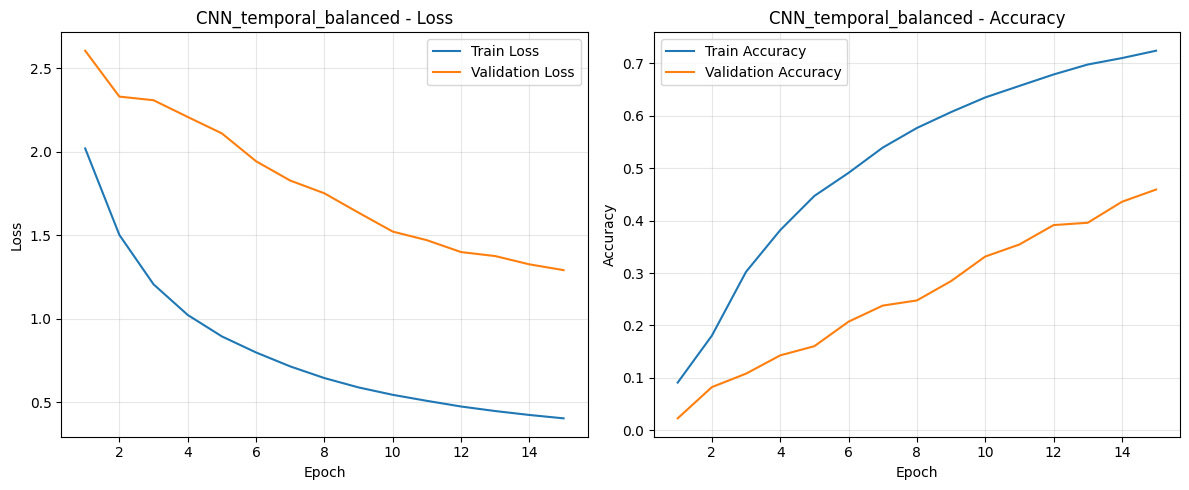

In [35]:
nicely_print('Temporal CNN', 'Training with Balanced Dataset')

# Train Balanced Model
print('\nTraining Balanced Temporal CNN:')
model_temporal_balanced = CNNTemporalPool(
    num_classes=num_classes,
    pool_type='mean',
    meta_hidden=8
).to(device)

model_temporal_balanced.freeze_weights()

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_temporal_balanced.parameters()),
    lr=1e-4
)

best_epoch_temporal_balanced, losses_temporal_balanced, accuracy_temporal_balanced = train_model_temporal(
    model=model_temporal_balanced,
    train_loader=train_loader_temporal_balanced,
    val_loader=val_loader_temporal,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=15,
    model_name_prefix=f'best_models/temporal/balanced/{model_name_prefix}_balanced'
)
plot_per_epoch(losses_temporal_balanced, accuracy_temporal_balanced, f'{model_name_prefix}_balanced')

# TODO:
# 1. pool_type = 'mean' / 'max'
#   You may check if we have time.
# 2. meta_hidden = 8 / 16 / 32
# 3. You may change the architecture of:
#   3a. Meta Branch: Add more hidden layers, add more meta features (logs, etc.)
#   3b. Classifier: Add more hidden layers
#
# If the model is still learning after the 50 epochs, you may train it for more epochs.

#### Model Evaluation

In [36]:
def predict_by_case_temporal(model, loader, device):
    model.eval()
    model.to(device)

    all_predictions = {}

    with torch.no_grad():
        for x, frame_norms, y, case_id in loader:
            x = x.to(device)
            y = y.to(device)
            frame_norms = frame_norms.to(device)

            out = model(x, frame_norms)           # (B, num_classes)
            preds = out.argmax(dim=1)             # (B,)

            for i in range(x.size(0)):
                cid = case_id[i]

                if isinstance(cid, torch.Tensor):
                    cid = cid.item()

                y_true_clip = int(y[i].cpu().item())
                y_pred_clip = int(preds[i].cpu().item())

                if cid not in all_predictions:
                    all_predictions[cid] = {
                        'y_true': [],
                        'y_pred': []
                    }

                all_predictions[cid]['y_true'].append(y_true_clip)
                all_predictions[cid]['y_pred'].append(y_pred_clip)

    return all_predictions

nicely_print('Temporal CNN', 'Prediction Function Definition')

Temporal CNN Prediction Function Definition



Temporal CNN (Balanced) Evaluation

Temporal CNN (Balanced) Results

All Together 

Case 18: 2776 frames


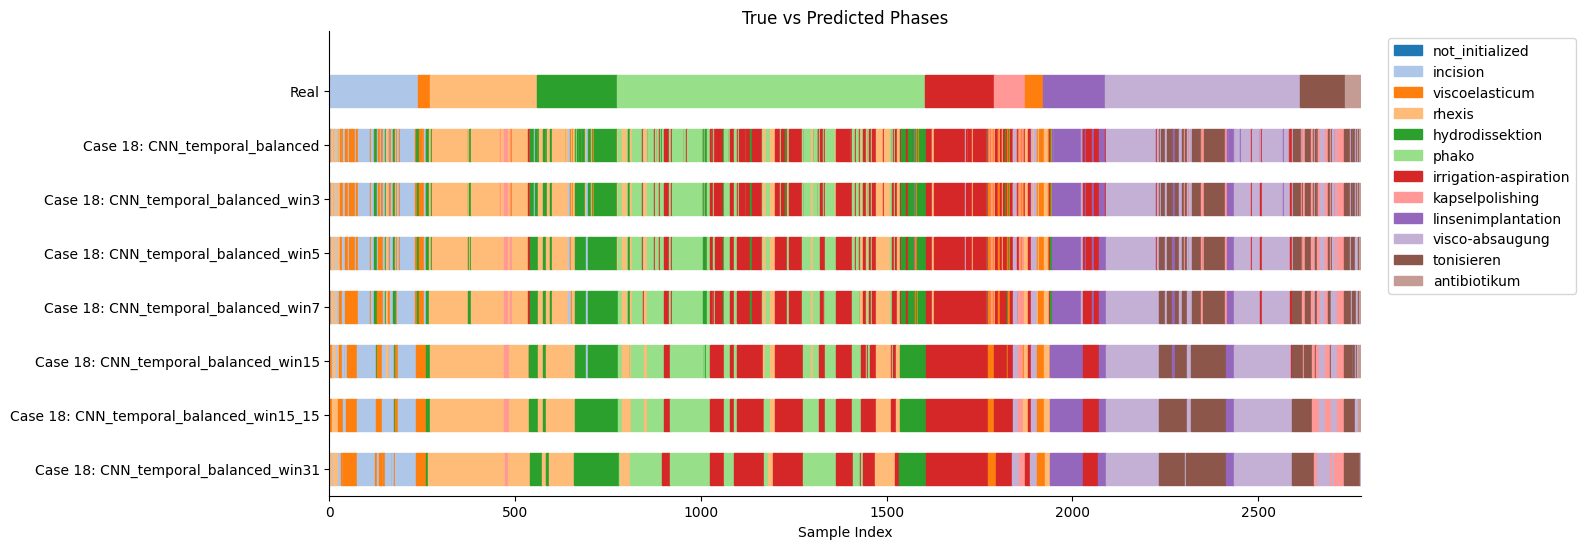


Case 19: 1237 frames


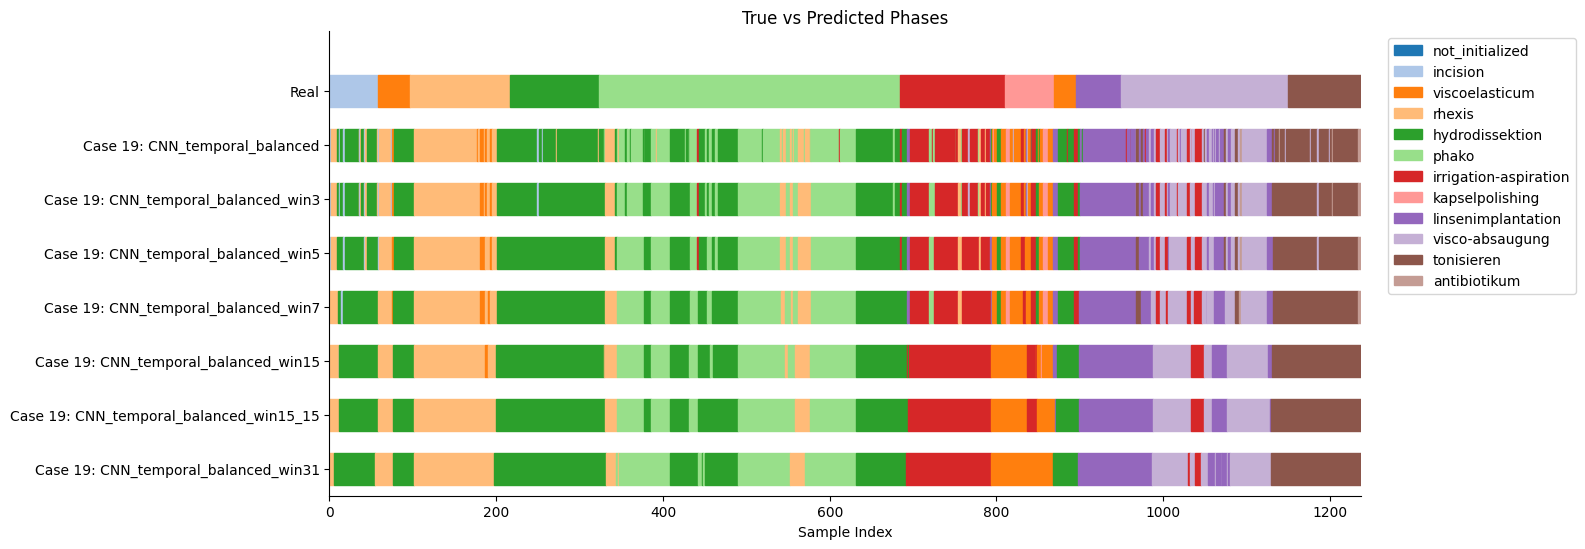


Case 20: 1430 frames


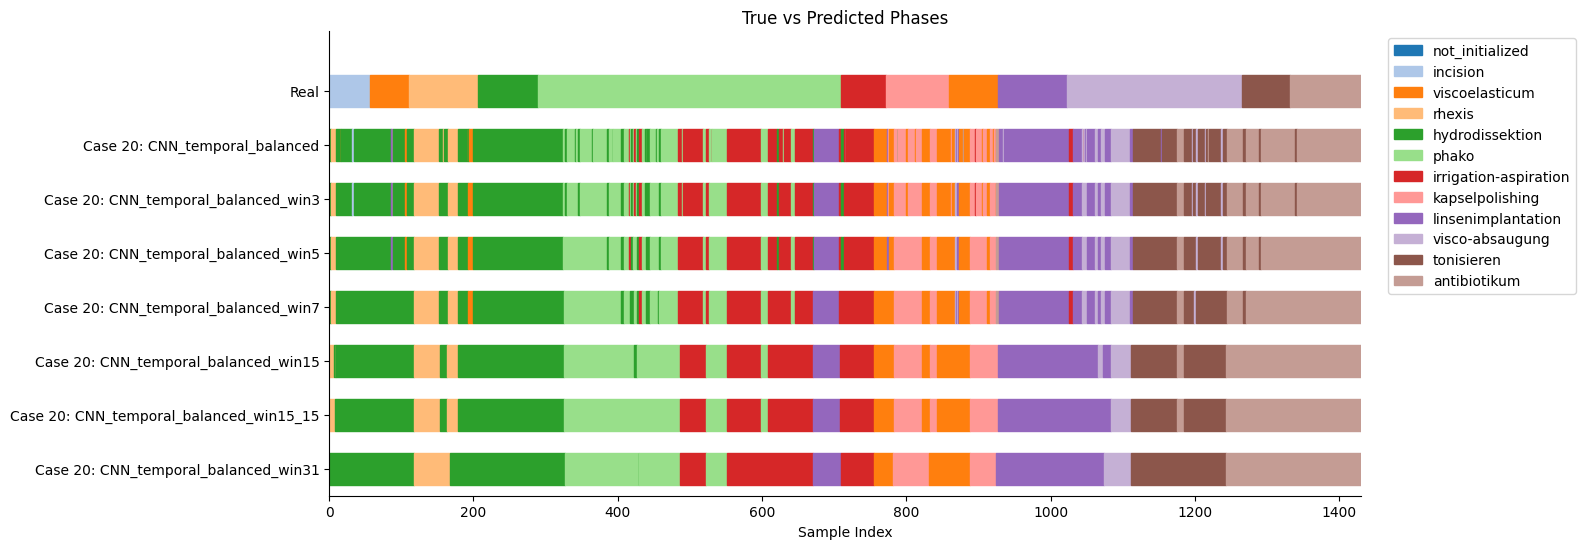


Case 21: 1958 frames


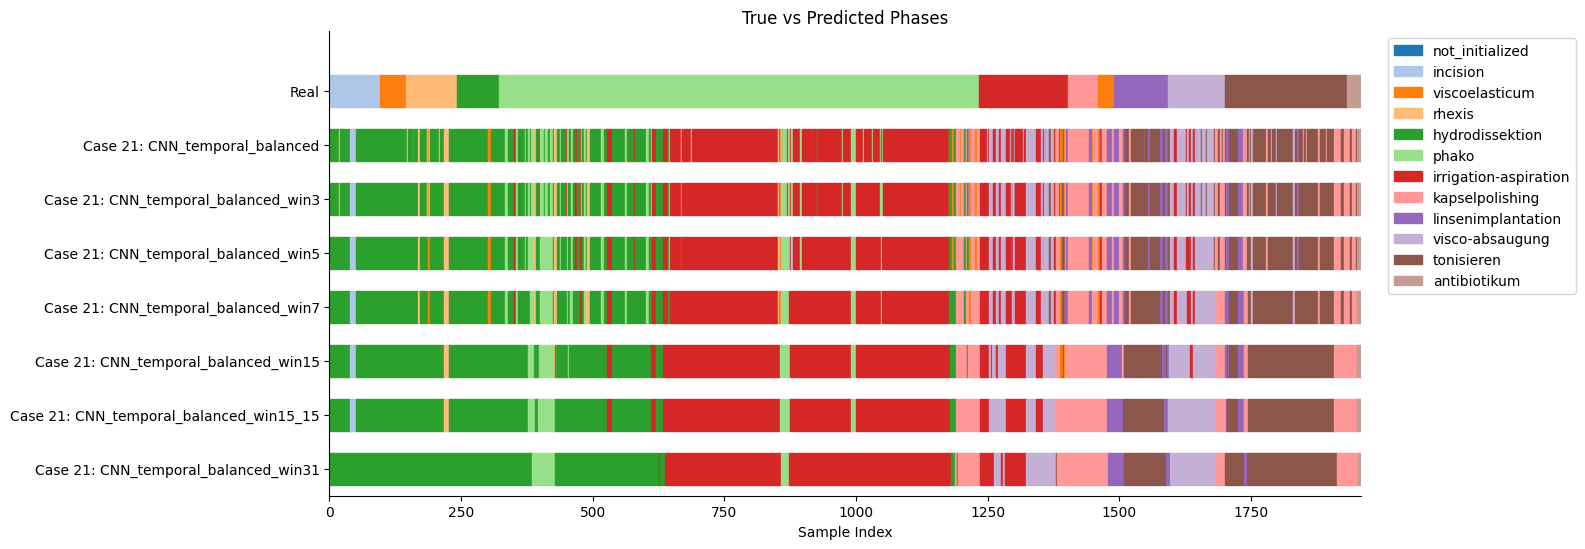



--- Overall Results for all cases (7401 frames) ---


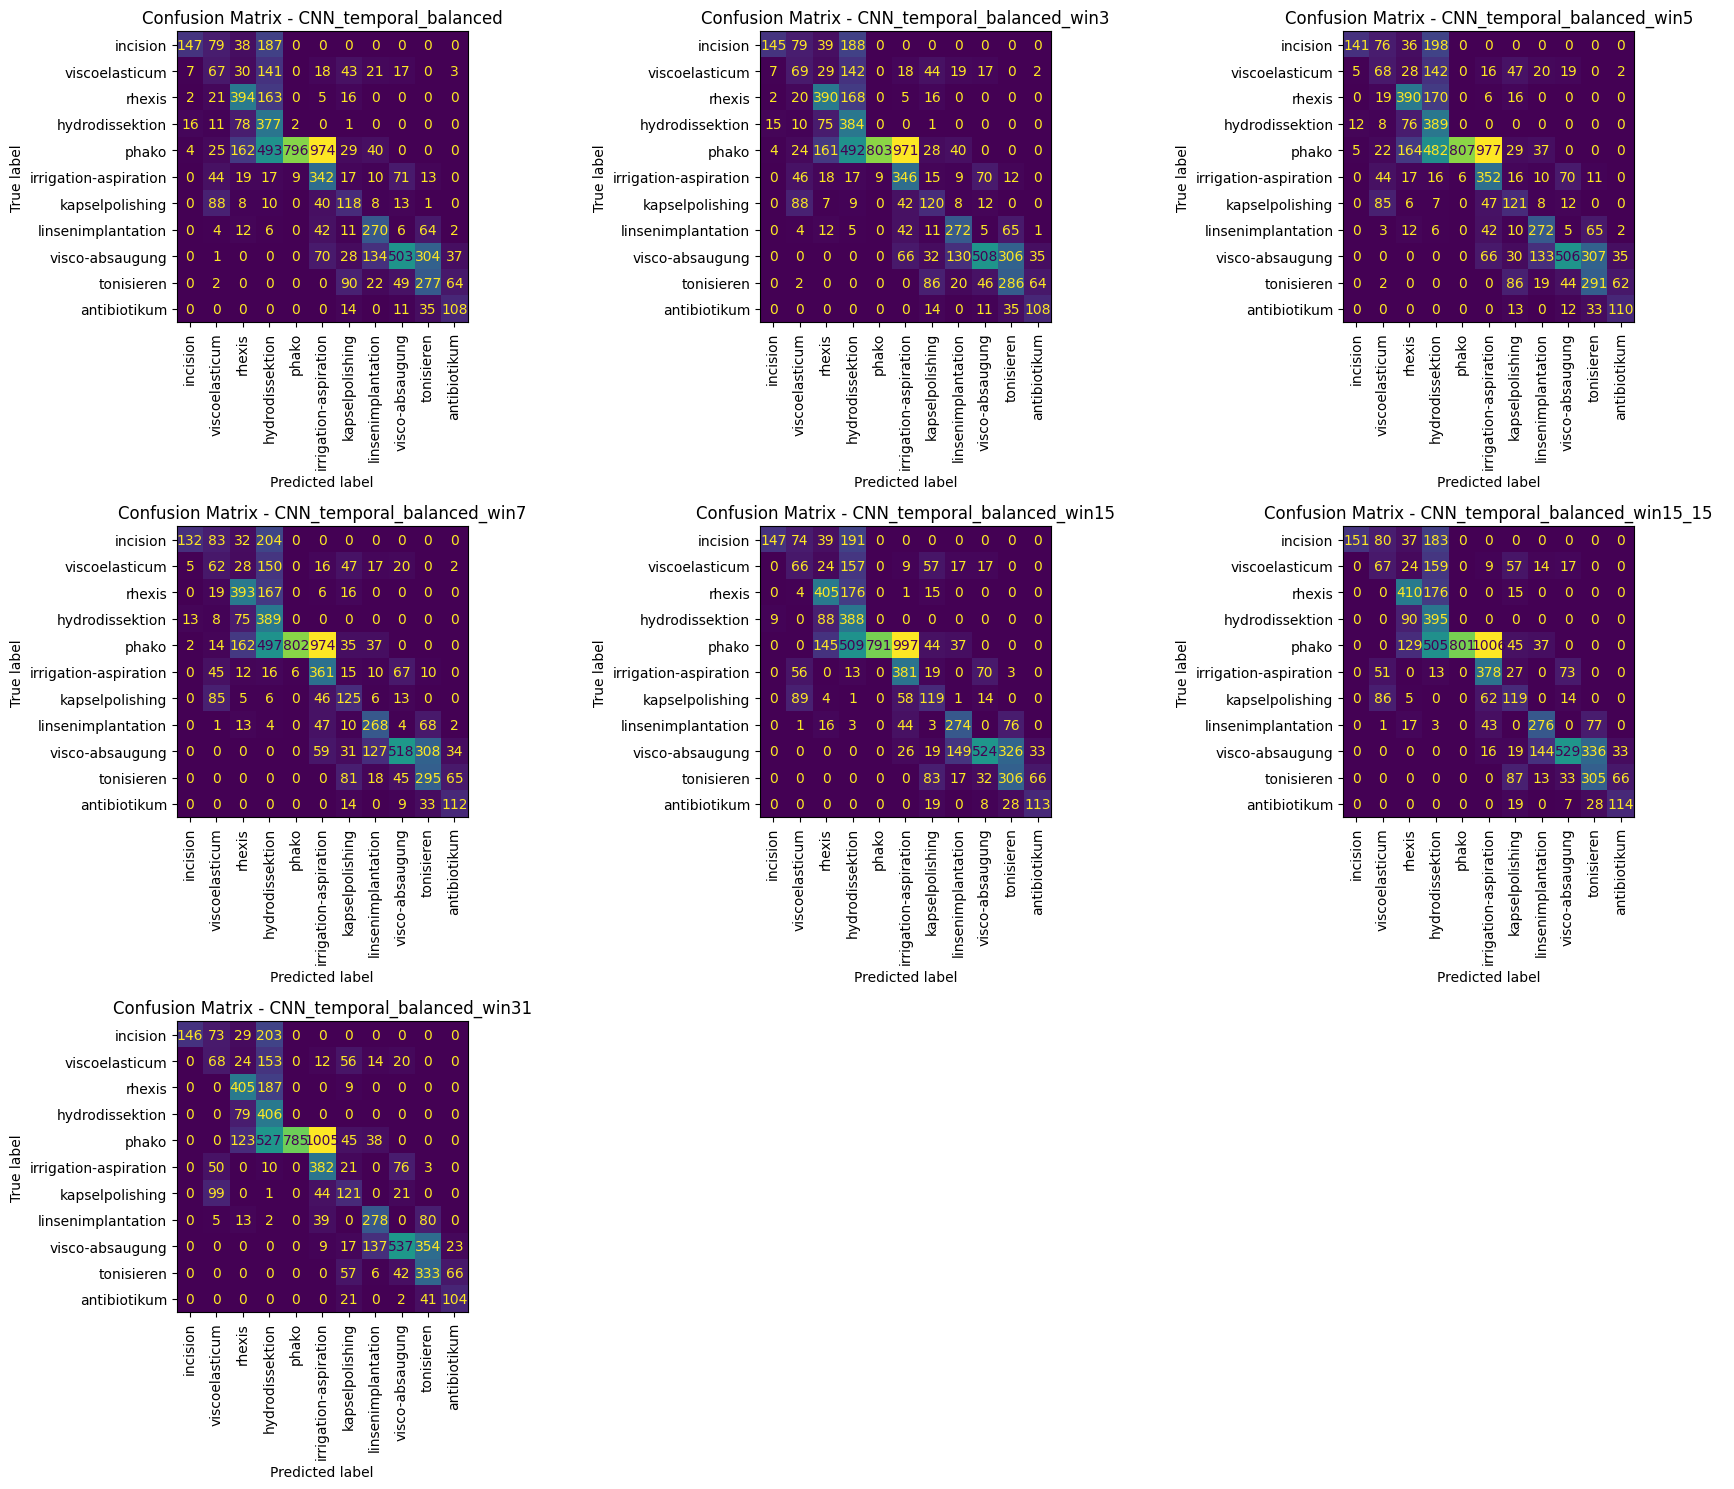

,Model,Accuracy,Precision,Recall,F1,Weighted F1
0,CNN_temporal_balanced,0.4593,0.6645,0.4593,0.4561,0.4744
1,CNN_temporal_balanced_win3,0.4636,0.6691,0.4636,0.4607,0.4786
2,CNN_temporal_balanced_win5,0.4657,0.6730,0.4657,0.4628,0.4801
3,CNN_temporal_balanced_win7,0.4671,0.6757,0.4671,0.4630,0.4807
4,CNN_temporal_balanced_win15,0.4748,0.6890,0.4748,0.4730,0.4876
5,CNN_temporal_balanced_win15_15,0.4790,0.6943,0.4790,0.4778,0.4924
6,CNN_temporal_balanced_win31,0.4817,0.6969,0.4817,0.4812,0.4932


In [38]:
best_epoch_temporal_balanced = (15,)

nicely_print('Temporal CNN (Balanced)', 'Evaluation')
model_temporal_balanced.load_state_dict(torch.load(f'best_models/temporal/balanced/{model_name_prefix}_balanced_epoch{best_epoch_temporal_balanced[0]}.pth', map_location=device))
model_temporal_balanced.to(device)
y_pred_temporal_balanced_by_case = predict_by_case_temporal(
    model=model_temporal_balanced,
    loader=val_loader_temporal,
    device=device
)

nicely_print('Temporal CNN (Balanced)', 'Results')
# evaluate_results(y_pred_temporal_balanced_by_case, f'{model_name_prefix}_balanced')
nicely_print('All Together')
evaluate_results(y_pred_temporal_balanced_by_case, f'{model_name_prefix}_balanced', together= True)